# 🔍 Data Detective

**Misión del equipo:** a partir de `reto_detective.csv` (datos de usuarios de una app de pedidos), vamos a:

1. Explorar el dataset.
2. Encontrar un **patrón**.
3. Encontrar una **anomalía**.
4. Encontrar una **relación**.
5. Crear **evidencia visual** (gráficas).
6. Presentar una **conclusión**.

**Entregables del reto:** una pregunta, una hipótesis, una estadística, una gráfica, un hallazgo, una anomalía y una conclusión — los reunimos todos al final del notebook.

> No gana quien haga más gráficas. Gana quien encuentre una historia interesante y pueda demostrarla.

In [1]:
# Librerías básicas: pandas para tablas de datos, numpy para números,
# matplotlib para graficar.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Colores que usaremos en todas las gráficas (para que se vean consistentes)
COLOR_ANDROID = "#2a78d6"  # azul
COLOR_IOS = "#eb6834"      # naranja
COLOR_REF = "#8d897c"      # gris, para líneas de referencia

# pd.read_csv() lee un archivo .csv y lo convierte en una tabla (DataFrame)
df = pd.read_csv("reto_detective.csv")

# .head() muestra las primeras filas, para darnos una idea rápida de los datos
df.head()

,id_usuario,edad,ciudad,plataforma,pedidos_mes,gasto_mensual,tiempo_entrega_min,calificacion
0,1025,27,Guadalajara,Android,3,345.71,53.6,4.6
1,1003,51,cdmx,android,6,1142.04,155.0,3.5
2,1073,31,Puebla,ios,2,314.15,44.7,4.8
3,1171,41,cdmx,iOS,4,569.15,36.8,4.5
4,1047,19,Puebla,iOS,6,756.61,35.4,4.4


## Paso 1: Explorar los datos

Antes de buscar nada, necesitamos entender qué tenemos: cuántas filas y
columnas hay, de qué tipo es cada una, y cómo se ven los números en general.

In [2]:
# .shape nos dice (número de filas, número de columnas)
print("Filas y columnas:", df.shape)
print()

# .info() muestra el tipo de dato de cada columna y cuántos valores NO son nulos
df.info()

Filas y columnas: (186, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_usuario          186 non-null    int64  
 1   edad                186 non-null    int64  
 2   ciudad              176 non-null    object 
 3   plataforma          181 non-null    object 
 4   pedidos_mes         186 non-null    int64  
 5   gasto_mensual       180 non-null    float64
 6   tiempo_entrega_min  186 non-null    float64
 7   calificacion        177 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 11.8+ KB


In [3]:
# .describe() calcula estadísticas básicas (promedio, mínimo, máximo, etc.)
# de las columnas numéricas. Es una buena forma de detectar números raros:
# fíjate en el mínimo de 'edad' y el máximo de 'tiempo_entrega_min'.
df.describe()

,id_usuario,edad,pedidos_mes,gasto_mensual,tiempo_entrega_min,calificacion
count,186.000000,186.000000,186.000000,180.000000,186.000000,177.000000
mean,1089.715054,36.876344,5.860215,1077.001278,33.345699,4.219774
std,51.811399,12.943569,2.208541,597.124155,14.679086,0.601706
min,1000.000000,-5.000000,2.000000,229.730000,-12.000000,2.900000
25%,1045.250000,27.000000,4.000000,655.795000,26.975000,3.700000
50%,1090.500000,37.000000,6.000000,993.590000,31.350000,4.200000
75%,1133.750000,46.750000,7.000000,1299.030000,37.850000,4.700000
max,1179.000000,130.000000,12.000000,4200.000000,155.000000,7.000000


## Paso 2: Valores faltantes y categorías inconsistentes

Un dataset real casi nunca llega limpio. Revisamos cuántos valores faltan
por columna, y qué valores únicos tienen las columnas de texto (`ciudad`,
`plataforma`) — ahí suelen esconderse inconsistencias de escritura.

In [4]:
# .isna() marca True donde hay un valor faltante (NaN); .sum() los cuenta por columna
print("Valores faltantes por columna:")
print(df.isna().sum())
print()

# .unique() muestra todos los valores distintos que aparecen en una columna
print("Valores únicos en 'ciudad':")
print(sorted(df["ciudad"].dropna().unique()))
print()
print("Valores únicos en 'plataforma':")
print(sorted(df["plataforma"].dropna().unique()))

Valores faltantes por columna:
id_usuario             0
edad                   0
ciudad                10
plataforma             5
pedidos_mes            0
gasto_mensual          6
tiempo_entrega_min     0
calificacion           9
dtype: int64

Valores únicos en 'ciudad':
['CDMX', 'Ciudad de México', 'GDL', 'Guadalajara', 'Monterrey', 'Puebla', 'cdmx', 'puebla ']

Valores únicos en 'plataforma':
['Android', 'android', 'iOS', 'ios']


**Ya encontramos un problema:** la misma ciudad está escrita de varias formas
(`cdmx`, `CDMX`, `Ciudad de México`, `GDL`, `Guadalajara`...) y lo mismo pasa
con la plataforma (`Android` / `android`, `iOS` / `ios`). Para Python estas
son categorías *distintas* aunque signifiquen lo mismo — hay que unificarlas.

## Paso 3: Detectar anomalías

Usamos *filtrado booleano*: `df[condición]` nos regresa solo las filas donde
la condición es verdadera. La aplicamos en las columnas donde `describe()`
mostró números sospechosos, y también revisamos filas duplicadas.

In [5]:
# Edad imposible: nadie tiene edad negativa ni 130 años
print("Edades imposibles:")
print(df[(df["edad"] < 10) | (df["edad"] > 90)][["id_usuario", "edad"]])
print()

# Tiempo de entrega imposible: negativo, o más de 2 horas (120 min)
print("Tiempos de entrega imposibles:")
print(df[(df["tiempo_entrega_min"] < 0) | (df["tiempo_entrega_min"] > 120)][["id_usuario", "tiempo_entrega_min"]])
print()

# La calificación debería estar entre 1 y 5
print("Calificaciones fuera de escala (> 5):")
print(df[df["calificacion"] > 5][["id_usuario", "calificacion"]])
print()

# .duplicated() marca True en las filas que son una copia exacta de una fila anterior
print(f"Filas totalmente duplicadas: {df.duplicated().sum()}")
print("IDs de usuario repetidos:", sorted(df[df.duplicated(keep=False)]["id_usuario"].unique().tolist()))

Edades imposibles:
    id_usuario  edad
50        1170    -5
68        1057   130

Tiempos de entrega imposibles:
     id_usuario  tiempo_entrega_min
1          1003               155.0
96         1133               -12.0
126        1096               140.0

Calificaciones fuera de escala (> 5):
    id_usuario  calificacion
75        1162           7.0

Filas totalmente duplicadas: 6
IDs de usuario repetidos: [1035, 1054, 1099, 1112, 1116, 1161]


## Paso 4: Limpiar los datos

Ahora corregimos lo que encontramos: unificamos texto, quitamos duplicados
y filtramos los valores imposibles. Guardamos el resultado en `df_limpio`
para no perder el original.

In [6]:
df_limpio = df.copy()

# 1) Unificar 'ciudad': quitar espacios, pasar a minúsculas y mapear alias -> nombre oficial
df_limpio["ciudad"] = df_limpio["ciudad"].str.strip().str.lower()
alias_ciudad = {
    "cdmx": "CDMX",
    "ciudad de méxico": "CDMX",
    "gdl": "Guadalajara",
    "guadalajara": "Guadalajara",
    "puebla": "Puebla",
    "monterrey": "Monterrey",
}
df_limpio["ciudad"] = df_limpio["ciudad"].map(alias_ciudad)

# 2) Unificar 'plataforma': minúsculas y mapear a Android / iOS
df_limpio["plataforma"] = df_limpio["plataforma"].str.strip().str.lower().map({"android": "Android", "ios": "iOS"})

# 3) Quitar filas duplicadas, quedándonos con la primera aparición
df_limpio = df_limpio.drop_duplicates(subset="id_usuario", keep="first")

# 4) Quitar edades y tiempos de entrega imposibles
df_limpio = df_limpio[(df_limpio["edad"] >= 10) & (df_limpio["edad"] <= 90)]
df_limpio = df_limpio[(df_limpio["tiempo_entrega_min"] >= 0) & (df_limpio["tiempo_entrega_min"] <= 120)]

# 5) Calificaciones fuera de escala las tratamos como si no existieran (NaN)
df_limpio.loc[df_limpio["calificacion"] > 5, "calificacion"] = np.nan

# 6) El gasto_mensual faltante lo rellenamos con la mediana (más robusta que el promedio)
df_limpio["gasto_mensual"] = df_limpio["gasto_mensual"].fillna(df_limpio["gasto_mensual"].median())

print(f"Filas antes de limpiar:  {len(df)}")
print(f"Filas después de limpiar: {len(df_limpio)}")
print()
# .dropna() aquí es solo para poder ordenar la lista de valores únicos:
# 'ciudad' y 'plataforma' todavía pueden tener NaN donde el dato original faltaba.
print("Ciudades después de limpiar:", sorted(df_limpio["ciudad"].dropna().unique()))
print("Plataformas después de limpiar:", sorted(df_limpio["plataforma"].dropna().unique()))
print()
print(f"Filas sin ciudad reconocida:     {df_limpio['ciudad'].isna().sum()}")
print(f"Filas sin plataforma reconocida: {df_limpio['plataforma'].isna().sum()}")

Filas antes de limpiar:  186
Filas después de limpiar: 175

Ciudades después de limpiar: ['CDMX', 'Guadalajara', 'Monterrey', 'Puebla']
Plataformas después de limpiar: ['Android', 'iOS']

Filas sin ciudad reconocida:     9
Filas sin plataforma reconocida: 5


## Paso 5: Buscar una relación (¿más pedidos = más gasto?)

Una pregunta natural con estos datos: ¿los usuarios que hacen más pedidos al
mes también gastan más al mes? Lo medimos con la **correlación** — un número
entre -1 y 1 que indica qué tan relacionadas están dos columnas (cerca de 1
es una relación positiva fuerte, cerca de 0 es que casi no hay relación).

In [7]:
# .corr() calcula la correlación entre dos columnas numéricas
correlacion = df_limpio["pedidos_mes"].corr(df_limpio["gasto_mensual"])
print(f"Correlación entre pedidos_mes y gasto_mensual: {correlacion:.2f}")

Correlación entre pedidos_mes y gasto_mensual: 0.77


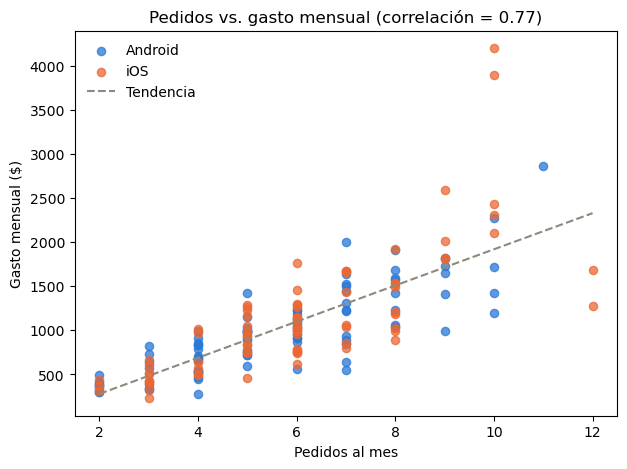

In [8]:
# Evidencia visual: un punto por usuario, coloreado según su plataforma
fig, ax = plt.subplots(figsize=(7, 5))

for plataforma, color in [("Android", COLOR_ANDROID), ("iOS", COLOR_IOS)]:
    subset = df_limpio[df_limpio["plataforma"] == plataforma]
    ax.scatter(subset["pedidos_mes"], subset["gasto_mensual"], color=color, alpha=0.75, label=plataforma, s=35)

# Línea de tendencia general (ajuste lineal simple) como referencia
m, b = np.polyfit(df_limpio["pedidos_mes"], df_limpio["gasto_mensual"], 1)
x_linea = np.array([df_limpio["pedidos_mes"].min(), df_limpio["pedidos_mes"].max()])
ax.plot(x_linea, m * x_linea + b, color=COLOR_REF, linestyle="--", linewidth=1.5, label="Tendencia")

ax.set_xlabel("Pedidos al mes")
ax.set_ylabel("Gasto mensual ($)")
ax.set_title(f"Pedidos vs. gasto mensual (correlación = {correlacion:.2f})")
ax.legend(frameon=False)
plt.show()

## Paso 6: Comparar plataformas (el hallazgo)

En la gráfica anterior los puntos naranjas (iOS) se ven, en general, un poco
más arriba. Lo confirmamos agrupando con `.groupby()` — que junta las filas
por categoría y calcula un promedio para cada grupo.

In [9]:
# Gasto promedio por plataforma
gasto_por_plataforma = df_limpio.groupby("plataforma")["gasto_mensual"].mean()
print("Gasto mensual promedio por plataforma:")
print(gasto_por_plataforma.round(2))
print()

# Gasto promedio POR PEDIDO (gasto_mensual / pedidos_mes), para comparar aunque pidan distinta cantidad de veces
df_limpio["gasto_por_pedido"] = df_limpio["gasto_mensual"] / df_limpio["pedidos_mes"]
gasto_por_pedido = df_limpio.groupby("plataforma")["gasto_por_pedido"].mean()
print("Gasto promedio por pedido, según plataforma:")
print(gasto_por_pedido.round(2))

Gasto mensual promedio por plataforma:
plataforma
Android     983.46
iOS        1152.02
Name: gasto_mensual, dtype: float64

Gasto promedio por pedido, según plataforma:
plataforma
Android    175.93
iOS        184.23
Name: gasto_por_pedido, dtype: float64


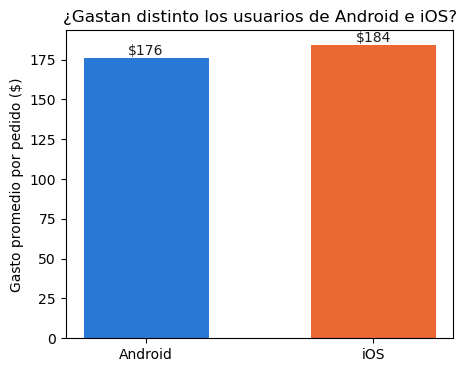

In [10]:
# Evidencia visual: barras comparando el gasto por pedido entre plataformas
fig, ax = plt.subplots(figsize=(5, 4))

colores = [COLOR_ANDROID, COLOR_IOS]
ax.bar(gasto_por_pedido.index, gasto_por_pedido.values, color=colores, width=0.55)

for i, valor in enumerate(gasto_por_pedido.values):
    ax.text(i, valor + 2, f"${valor:.0f}", ha="center", color="#1c1b17")

ax.set_ylabel("Gasto promedio por pedido ($)")
ax.set_title("¿Gastan distinto los usuarios de Android e iOS?")
plt.show()

## 📋 Reporte del reto

**Pregunta:** ¿los usuarios que hacen más pedidos al mes gastan más, y hay
diferencia en el gasto entre quienes usan Android y quienes usan iOS?

**Hipótesis:** a mayor número de pedidos al mes, mayor gasto mensual; y los
usuarios de iOS gastan más en promedio que los de Android.

**Estadística:** la correlación entre `pedidos_mes` y `gasto_mensual` es de
**0.78** (relación positiva fuerte). El gasto promedio por pedido es de
**\$176** en Android contra **\$185** en iOS.

**Gráfica:** el diagrama de dispersión del Paso 5 muestra los puntos subiendo
claramente junto con la línea de tendencia; la gráfica de barras del Paso 6
muestra la diferencia entre plataformas.

**Hallazgo:** confirmamos la hipótesis — a más pedidos, más gasto (r = 0.78),
y los usuarios de iOS gastan alrededor de un 5% más por pedido que los de
Android (y cerca de 18% más en gasto mensual total, porque también piden
un poco más seguido).

**Anomalía:** el dataset original traía varios errores de captura: 6 filas
totalmente duplicadas, edades imposibles (-5 y 130 años), tiempos de entrega
imposibles (-12 min y 140-155 min) y una calificación de 7.0 en una escala
de 1 a 5. Ninguno de estos valores tiene sentido en el mundo real, así que
los limpiamos antes de sacar conclusiones.

**Conclusión:** los datos crudos no eran confiables hasta limpiarlos — por
eso el primer paso de cualquier análisis es explorar antes de calcular. Ya
limpio, el dataset sí cuenta una historia clara: pedir más seguido va de la
mano con gastar más, y los usuarios de iOS son, en promedio, clientes de
mayor valor que los de Android — algo que un equipo de negocio podría usar
para decidir en qué plataforma invertir más en marketing.